<a href="https://colab.research.google.com/github/Rajfekar/PythonML/blob/main/CLIP%20MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-4dep69ro
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-4dep69ro
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=52a22c9420f46b3b5ca8122f1722b81c61a5c25165e6c6274c03addc775b8b39
  Stored in directory: /tmp/pip-ephem-wheel-cache-3_4zd78k/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt

In [16]:
# CLIP learns the relationship between images and text.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print("CLIP model loaded")

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 60.3MiB/s]


CLIP model loaded


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fox.jpg to fox.jpg


(np.float64(-0.5), np.float64(312.5), np.float64(273.5), np.float64(-0.5))

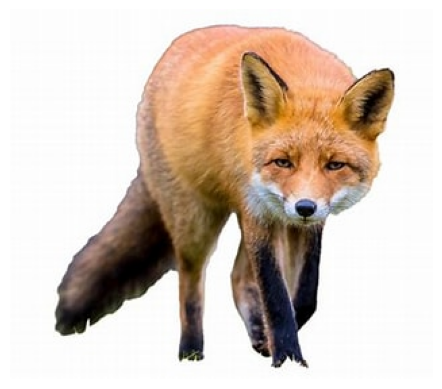

In [ ]:
image = preprocess(Image.open("fox.jpg")).unsqueeze(0).to(device)

plt.imshow(Image.open("fox.jpg"))
plt.axis("off")

(np.float64(-0.5), np.float64(312.5), np.float64(273.5), np.float64(-0.5))

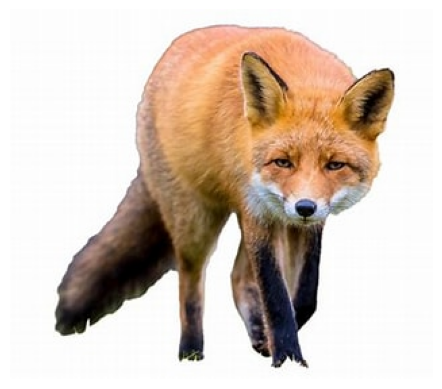

In [ ]:
image = preprocess(Image.open("fox.jpg")).unsqueeze(0).to(device)

plt.imshow(Image.open("fox.jpg"))
plt.axis("off")

In [ ]:
text = clip.tokenize([
    "a red fox wearing sunglasses",
    "a dog running in snow",
    "a cat sitting on laptop"
]).to(device)

In [17]:
# CLIP was trained on millions of image–text pairs.

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)

In [ ]:
similarity = (image_features @ text_features.T).softmax(dim=-1)

print("Similarity scores:", similarity)

Similarity scores: tensor([[9.9978e-01, 5.2168e-05, 1.7192e-04]])


In [ ]:
labels = [
    "a red fox wearing sunglasses",
    "a dog running in snow",
    "a cat sitting on laptop"
]

probs = similarity.cpu().numpy()[0]

for label, p in zip(labels, probs):
    print(f"{label}: {p*100:.4f}%")

a red fox wearing sunglasses: 99.9776%
a dog running in snow: 0.0052%
a cat sitting on laptop: 0.0172%


In [ ]:
labels = ["fox wearing sunglasses", "dog running in snow", "cat on laptop"]

best_match = similarity.argmax().item()

print("Best caption:", labels[best_match])

Best caption: fox wearing sunglasses


In [ ]:
# CLIP learns the relationship between images and text by encoding them into the same vector space.

# The model contains two encoders:

# Image Encoder

# Text Encoder

# Both produce embeddings (vectors).

# Then the model computes similarity between the vectors.